# The GE Model: From Trade Costs to Welfare

This notebook walks through the spatial general equilibrium model we use, step by step. We'll work through a **3-location example** on paper, then connect it to the full Tanzania computation.

**The model answers:** If trade costs change (e.g., we pave all roads), what happens to wages, prices, population, and welfare in every location?

**What you'll learn:**
1. What "general equilibrium" means and why partial equilibrium isn't enough
2. Trade shares and the gravity equation
3. How to invert the model (recover fundamentals from data)
4. The hat algebra (counterfactuals without re-solving the model)
5. The welfare formula and what it means

## 1. Why General Equilibrium?

**Partial equilibrium** says: "If we pave the road between A and B, trade between A and B gets cheaper." That's true but incomplete.

**General equilibrium** adds: "...and workers in A now face more competition from B's producers, so A's wages adjust downward. Meanwhile, workers move from C to B because B is now better connected. C's land prices fall. B's land prices rise. The price of every good in every location changes. Some places that aren't even on the paved road are affected because their trading partners changed."

GE captures all these **spillovers and feedbacks**. That's why the aggregate welfare gain isn't just the sum of pairwise trade cost reductions — it's the result of the entire economy re-equilibrating.

Let's build this from scratch with 3 locations.

## 2. The Setup: A 3-Location Economy

Imagine three districts in Tanzania:

| Location | Think of it as... | Population | Productivity |
|----------|-------------------|------------|-------------|
| A | Dar es Salaam (big, productive, well-connected) | 2,000 | High |
| B | Dodoma (medium, moderate) | 1,000 | Medium |
| C | Remote rural district (small, less productive) | 500 | Low |

They trade with each other, subject to **iceberg trade costs** $d_{ni}$:

| From \ To | A | B | C |
|-----------|---|---|---|
| A | 1.0 | 1.5 | 3.0 |
| B | 1.5 | 1.0 | 2.0 |
| C | 3.0 | 2.0 | 1.0 |

**Iceberg cost $d_{ni} = 1.5$** means: to deliver 1 unit of goods from $i$ to $n$, you must ship 1.5 units (0.5 units "melt" in transit — fuel, time, spoilage). Trading with yourself costs 1.0 (no loss).

C is remote: it costs 3.0 to ship to/from A, and 2.0 to/from B.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
sigma = 5.0    # elasticity of substitution (how easily consumers switch between goods)
alpha = 0.65   # share of income spent on goods (rest on land/housing)

# 3 locations
names = ['A (Dar)', 'B (Dodoma)', 'C (Rural)']
n = 3

# Trade costs (iceberg)
d = np.array([
    [1.0, 1.5, 3.0],  # costs FROM A, B, C TO location A
    [1.5, 1.0, 2.0],  # costs FROM A, B, C TO location B
    [3.0, 2.0, 1.0],  # costs FROM A, B, C TO location C
])

# Population
L = np.array([2000, 1000, 500])

# Productivity (we'll calibrate this, but start with reasonable values)
A = np.array([2.0, 1.0, 0.5])

print("Trade cost matrix (d_ni):")
print(f"  d[n,i] = cost of shipping from location i to location n")
for i in range(n):
    print(f"  {names[i]}: {d[i]}")

Trade cost matrix (d_ni):
  d[n,i] = cost of shipping from location i to location n
  A (Dar): [1.  1.5 3. ]
  B (Dodoma): [1.5 1.  2. ]
  C (Rural): [3. 2. 1.]


## 3. Trade Shares: Who Buys From Whom?

The **trade share** $\pi_{ni}$ is the fraction of location $n$'s spending that goes to goods from location $i$.

The formula (from the CES demand system):

$$\pi_{ni} = \frac{L_i \left(\frac{d_{ni} w_i}{A_i}\right)^{1-\sigma}}{\sum_k L_k \left(\frac{d_{nk} w_k}{A_k}\right)^{1-\sigma}}$$

**What this says:**
- Location $n$ buys more from $i$ if:
  - $i$ is productive (high $A_i$ → low unit cost)
  - $i$ has low wages (low $w_i$ → cheap labor)
  - Trade costs $d_{ni}$ are low (nearby, good roads)
  - $i$ is large (high $L_i$ → more varieties to choose from)
- The denominator normalizes so all shares sum to 1

With $\sigma = 5$, the exponent is $1 - \sigma = -4$. This means trade costs have a **strong** effect: doubling $d$ reduces the trade share by $2^4 = 16$ times.

Let's compute:

In [3]:
# First, we need wages. Start with w proportional to productivity.
w = A * 1000  # arbitrary scale — wages in Dar are higher

# Compute trade shares
def compute_trade_shares(d, w, A, L, sigma):
    """Compute trade share matrix pi[n,i] = share of n's spending on goods from i."""
    nn = len(L)
    # Numerator: L_i * (d_ni * w_i / A_i)^(1-sigma) for each (n,i)
    cost = d * w[np.newaxis, :] / A[np.newaxis, :]  # d_ni * w_i / A_i
    numerator = L[np.newaxis, :] * cost**(1 - sigma)
    # Denominator: sum over all sources k
    denominator = numerator.sum(axis=1, keepdims=True)
    pi = numerator / denominator
    return pi

pi = compute_trade_shares(d, w, A, L, sigma)

print("Trade shares pi[n,i]:")
print(f"  Row = buyer (n), Column = seller (i)")
print(f"  Each row sums to 1.0\n")

header = f"{'Buyer':<12s}" + "".join(f"{name:>14s}" for name in names) + f"{'Sum':>8s}"
print(header)
print("-" * len(header))
for i in range(n):
    row = f"{names[i]:<12s}"
    for j in range(n):
        row += f"{pi[i,j]:>14.3f}"
    row += f"{pi[i,:].sum():>8.3f}"
    print(row)

print(f"\nDomestic trade shares (diagonal):")
for i in range(n):
    print(f"  {names[i]}: pi_nn = {pi[i,i]:.3f} — buys {100*pi[i,i]:.1f}% of goods locally")

Trade shares pi[n,i]:
  Row = buyer (n), Column = seller (i)
  Each row sums to 1.0

Buyer              A (Dar)    B (Dodoma)     C (Rural)     Sum
--------------------------------------------------------------
A (Dar)              0.908         0.090         0.003   1.000
B (Dodoma)           0.277         0.701         0.022   1.000
C (Rural)            0.042         0.106         0.852   1.000

Domestic trade shares (diagonal):
  A (Dar): pi_nn = 0.908 — buys 90.8% of goods locally
  B (Dodoma): pi_nn = 0.701 — buys 70.1% of goods locally
  C (Rural): pi_nn = 0.852 — buys 85.2% of goods locally


**What to notice:**

- **A (Dar)** has a moderate domestic share — it's productive so it buys a lot from itself, but also imports from B.
- **C (Rural)** has a high domestic share — trade costs are so high that it's essentially forced to consume its own (lower quality) goods. This is the **cost of being remote with bad roads.**
- The domestic trade share $\pi_{nn}$ is the key object for welfare. A lower $\pi_{nn}$ means more trade, more variety, lower prices.

## 4. The Gravity Equation

The trade share formula implies a **gravity equation**: bilateral trade between two places increases with their sizes and decreases with the distance (trade cost) between them.

$$\text{Trade}_{ni} \propto \frac{L_n \cdot L_i}{d_{ni}^{\sigma-1}}$$

This is the same gravity equation used in international trade since Tinbergen (1962). In our context:
- Larger districts trade more (more people = more demand and supply)
- Districts with better roads between them trade more
- The elasticity $\sigma - 1 = 4$ is how sensitive trade is to distance

Let's visualize:

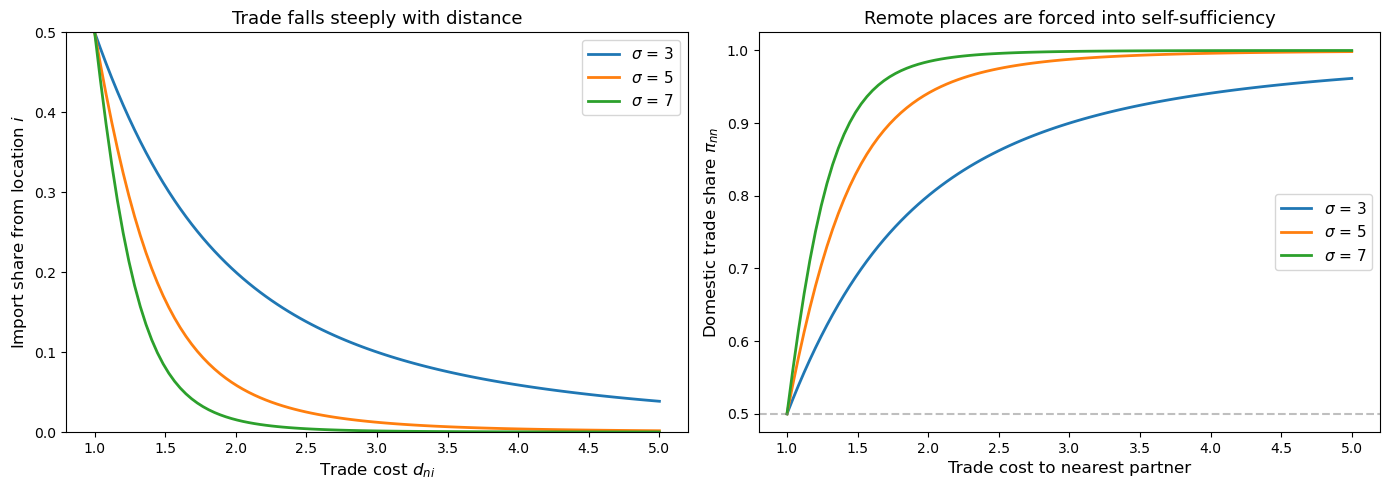

Key insight: when trade costs are high (bad roads), pi_nn is close to 1.
The location is trapped in autarky — consuming only what it produces.
Paving roads reduces d, which reduces pi_nn, which increases welfare.


In [4]:
# Show how trade shares vary with distance
distances = np.linspace(1.0, 5.0, 100)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: trade share vs distance for different sigma
for s in [3, 5, 7]:
    shares = distances**(1-s) / (1.0**(1-s) + distances**(1-s))  # simplified 2-location
    ax1.plot(distances, shares, label=f'$\\sigma$ = {s}', linewidth=2)

ax1.set_xlabel('Trade cost $d_{ni}$', fontsize=12)
ax1.set_ylabel('Import share from location $i$', fontsize=12)
ax1.set_title('Trade falls steeply with distance', fontsize=13)
ax1.legend(fontsize=11)
ax1.set_ylim(0, 0.5)

# Right: domestic trade share vs trade cost to nearest trading partner
for s in [3, 5, 7]:
    pi_nn = 1.0**(1-s) / (1.0**(1-s) + distances**(1-s))
    ax2.plot(distances, pi_nn, label=f'$\\sigma$ = {s}', linewidth=2)

ax2.set_xlabel('Trade cost to nearest partner', fontsize=12)
ax2.set_ylabel('Domestic trade share $\\pi_{nn}$', fontsize=12)
ax2.set_title('Remote places are forced into self-sufficiency', fontsize=13)
ax2.legend(fontsize=11)
ax2.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("Key insight: when trade costs are high (bad roads), pi_nn is close to 1.")
print("The location is trapped in autarky — consuming only what it produces.")
print("Paving roads reduces d, which reduces pi_nn, which increases welfare.")

## 5. Model Inversion: Recovering Fundamentals

In the real world, we observe $L_i$ (population) and $Y_i$ (GDP) but not $A_i$ (productivity). The model tells us there's a unique set of productivities that makes the observed data an equilibrium. **Inversion** means solving for those productivities.

The logic:
1. We observe that Dar has high population AND high GDP per capita
2. The model says: a location with high population must have either high productivity, high amenities, or low trade costs (or some combination)
3. Given the trade costs (from the road network), we can back out what productivity $A_i$ must be to rationalize the data

Technically: given $\{L_i, w_i, d_{ni}\}$, find $\{A_i\}$ such that market clearing holds:

$$Y_i = \sum_n \pi_{ni} \cdot Y_n$$

"Location $i$'s income = total spending by all locations on $i$'s goods."

We iterate: guess $A$, compute trade shares, check market clearing, adjust $A$, repeat.

In [5]:
# Model inversion for our 3-location example
# Given: L, Y (=w*L), d, sigma
# Find: A such that market clearing holds

Y = np.array([4000, 1500, 400])  # GDP (Dar > Dodoma > Rural)
w = Y / L  # wages

print(f"Observed data:")
for i in range(n):
    print(f"  {names[i]}: L={L[i]}, Y={Y[i]}, w={w[i]:.2f}")

# Iterate to find A
A_guess = np.ones(n)  # start with equal productivity

print(f"\nInversion iterations:")
for iteration in range(20):
    # Compute trade shares with current A
    pi = compute_trade_shares(d, w, A_guess, L, sigma)
    
    # Market clearing: Y_predicted_i = sum_n pi[n,i] * Y[n]
    Y_predicted = pi.T @ Y
    
    # Update A to close the gap
    ratio = Y / Y_predicted
    A_guess = A_guess * ratio**0.3  # dampened update
    
    error = np.max(np.abs(ratio - 1))
    if iteration < 5 or error < 0.01:
        print(f"  Iter {iteration:2d}: A = [{A_guess[0]:.3f}, {A_guess[1]:.3f}, {A_guess[2]:.3f}], "
              f"max error = {error:.4f}")
    if error < 0.001:
        print(f"  Converged!")
        break

# Final trade shares
pi = compute_trade_shares(d, w, A_guess, L, sigma)

print(f"\nRecovered productivities:")
for i in range(n):
    print(f"  {names[i]}: A = {A_guess[i]:.3f}")

print(f"\nVerification (market clearing):")
Y_check = pi.T @ Y
for i in range(n):
    print(f"  {names[i]}: Y_observed={Y[i]:.0f}, Y_predicted={Y_check[i]:.0f}, "
          f"error={abs(Y_check[i]/Y[i]-1)*100:.2f}%")

Observed data:
  A (Dar): L=2000, Y=4000, w=2.00
  B (Dodoma): L=1000, Y=1500, w=1.50
  C (Rural): L=500, Y=400, w=0.80

Inversion iterations:
  Iter  0: A = [1.099, 0.936, 0.735], max error = 0.6414
  Iter  1: A = [1.132, 0.910, 0.642], max error = 0.3625
  Iter  2: A = [1.147, 0.902, 0.591], max error = 0.2401
  Iter  3: A = [1.156, 0.899, 0.560], max error = 0.1662
  Iter  4: A = [1.161, 0.898, 0.540], max error = 0.1170
  Iter 12: A = [1.171, 0.898, 0.497], max error = 0.0072
  Iter 13: A = [1.171, 0.898, 0.497], max error = 0.0050
  Iter 14: A = [1.171, 0.898, 0.496], max error = 0.0035
  Iter 15: A = [1.171, 0.898, 0.496], max error = 0.0025
  Iter 16: A = [1.171, 0.898, 0.495], max error = 0.0017
  Iter 17: A = [1.171, 0.898, 0.495], max error = 0.0012
  Iter 18: A = [1.171, 0.898, 0.495], max error = 0.0009
  Converged!

Recovered productivities:
  A (Dar): A = 1.171
  B (Dodoma): A = 0.898
  C (Rural): A = 0.495

Verification (market clearing):
  A (Dar): Y_observed=4000, Y_pr

**What just happened:**

We found the unique productivities $A_i$ that rationalize the data. Dar has the highest productivity (it earns high GDP despite facing competition from imports). The rural district has low productivity (its GDP is low even though high trade costs protect it from competition).

This is what `calibrate.py` does for 186 districts.

## 6. The Hat Algebra: Counterfactuals Made Easy

Now the payoff. We want to know: **what if we pave all roads?**

We could re-solve the entire model from scratch with new trade costs. But there's a shortcut: the **hat algebra** (Dekle, Eaton & Kortum 2007).

**The idea:** Express everything as **ratios** to the baseline. Define $\hat{x} = x'/x$ (counterfactual over baseline). Then the equilibrium conditions become a system in the ratios $\{\hat{w}_i, \hat{\pi}_{ni}, \hat{\lambda}_n\}$.

**Why this is powerful:** You don't need to know the productivity levels $A_i$ at all! The hat algebra cancels them out. You only need:
- Baseline wages $w_i$ (observed)
- Baseline trade shares $\pi_{ni}$ (computed from calibration)
- Trade cost **changes** $\hat{d}_{ni} = d'_{ni} / d_{ni}$ (from the road network)

The three equations (Redding & Rossi-Hansberg 2017):

**Eq 19 — Trade shares change:**
$$\pi'_{ni} = \frac{\pi_{ni} (\hat{d}_{ni} \hat{w}_i)^{1-\sigma} \hat{L}_i}{\sum_k \pi_{nk} (\hat{d}_{nk} \hat{w}_k)^{1-\sigma} \hat{L}_k}$$

**Eq 20 — Population reallocates:**
$$\hat{\lambda}_n = \frac{\hat{\pi}_{nn}^{-\gamma}}{\sum_k \hat{\pi}_{kk}^{-\gamma} \lambda_k}$$
where $\gamma = \alpha / (\sigma(1-\alpha) - 1)$

**Eq 18 — Wages adjust (market clearing):**
$$\hat{w}_i = \frac{\sum_n \pi'_{ni} \hat{w}_n \hat{\lambda}_n (w_n \lambda_n)}{\hat{\lambda}_i (w_i \lambda_i)}$$

We iterate on these three equations until convergence. Let's do it for our 3-location example:

In [6]:
# Counterfactual: pave all roads
# New trade costs (everything improves, especially routes to C)
d_new = np.array([
    [1.0, 1.2, 1.5],  # A-C drops from 3.0 to 1.5 (paving the remote road)
    [1.2, 1.0, 1.3],  # B-C drops from 2.0 to 1.3
    [1.5, 1.3, 1.0],  
])

# Trade cost changes (hat)
d_hat = d_new / d

print("Trade cost changes (d_hat = d'/d):")
for i in range(n):
    for j in range(n):
        if i != j:
            pct = 100*(1 - d_hat[i,j])
            print(f"  {names[j]} -> {names[i]}: d_hat = {d_hat[i,j]:.3f} ({pct:+.0f}% reduction)")

# Baseline values
lam = L / L.sum()
wl = w * lam
pi_nn = np.diag(pi)

gamma = alpha / (sigma * (1 - alpha) - 1)
print(f"\nPopulation mobility parameter gamma = {gamma:.4f}")

# ═══════════════════════════════════════════════════════════
# STAGE 1: Fix population, solve for wages only
# This is stable because we only update one set of variables
# ═══════════════════════════════════════════════════════════
print(f"\n--- Stage 1: Fixed population (wages only) ---")
w_hat = np.ones(n)

for iteration in range(2000):
    w_hat_old = w_hat.copy()
    
    # Eq 19: trade shares (with L_hat = 1, fixed population)
    factor = (d_hat * w_hat[np.newaxis, :])**(1 - sigma)
    numerator = pi * factor
    pi_prime = numerator / numerator.sum(axis=1, keepdims=True)
    
    # Eq 18: market clearing for wages (with lam_hat = 1)
    rhs = pi_prime.T @ (w_hat * wl)
    w_hat_new = rhs / wl
    
    w_hat = w_hat**0.7 * w_hat_new**0.3  # dampened
    w_hat = w_hat / np.average(w_hat, weights=wl)
    
    diff = np.max(np.abs(np.log(w_hat) - np.log(w_hat_old)))
    if iteration < 3:
        print(f"  Iter {iteration}: w_hat = [{w_hat[0]:.4f}, {w_hat[1]:.4f}, {w_hat[2]:.4f}], diff = {diff:.2e}")
    if diff < 1e-10:
        print(f"  Converged at iteration {iteration}!")
        break

# Stage 1 results
pi_nn_prime_s1 = np.diag(pi_prime)
print(f"\nStage 1 wage changes (no mobility):")
for i in range(n):
    print(f"  {names[i]}: w_hat = {w_hat[i]:.4f} ({100*(w_hat[i]-1):+.1f}%)")

# ═══════════════════════════════════════════════════════════
# STAGE 2: Now add population mobility starting from Stage 1
# ═══════════════════════════════════════════════════════════
print(f"\n--- Stage 2: Adding population mobility ---")
lam_hat = np.ones(n)

for iteration in range(2000):
    w_hat_old = w_hat.copy()
    lam_hat_old = lam_hat.copy()
    L_hat = lam_hat
    
    # Eq 19: trade shares (now with L_hat)
    factor = (d_hat * w_hat[np.newaxis, :])**(1 - sigma) * L_hat[np.newaxis, :]
    numerator = pi * factor
    pi_prime = numerator / numerator.sum(axis=1, keepdims=True)
    
    pi_nn_prime = np.diag(pi_prime)
    pi_nn_hat = pi_nn_prime / pi_nn
    
    # Eq 20: population
    pi_nn_hat_exp = np.maximum(pi_nn_hat, 1e-20)**(-gamma)
    lam_hat_new = pi_nn_hat_exp / np.sum(pi_nn_hat_exp * lam)
    
    # Eq 18: wages
    rhs = pi_prime.T @ (w_hat * lam_hat * wl)
    w_hat_new = rhs / np.maximum(lam_hat * wl, 1e-20)
    
    # Very conservative dampening
    w_hat = w_hat**0.9 * np.clip(w_hat_new, 0.5, 2.0)**0.1
    lam_hat = lam_hat**0.9 * np.clip(lam_hat_new, 0.5, 2.0)**0.1
    w_hat = w_hat / np.average(w_hat, weights=wl)
    
    diff = max(np.max(np.abs(np.log(w_hat) - np.log(w_hat_old))),
               np.max(np.abs(np.log(lam_hat) - np.log(lam_hat_old))))
    if iteration < 3:
        print(f"  Iter {iteration}: diff = {diff:.2e}")
    if diff < 1e-10:
        print(f"  Converged at iteration {iteration}!")
        break

print(f"\nFinal results:")
print(f"\nWage changes:")
for i in range(n):
    print(f"  {names[i]}: w_hat = {w_hat[i]:.4f} ({100*(w_hat[i]-1):+.1f}%)")

print(f"\nPopulation changes:")
for i in range(n):
    print(f"  {names[i]}: L_hat = {lam_hat[i]:.4f} ({100*(lam_hat[i]-1):+.1f}%)")

print(f"\nDomestic trade shares:")
for i in range(n):
    print(f"  {names[i]}: {pi_nn[i]:.3f} -> {pi_nn_prime[i]:.3f} ({100*(pi_nn_prime[i]/pi_nn[i]-1):+.1f}%)")

Trade cost changes (d_hat = d'/d):
  B (Dodoma) -> A (Dar): d_hat = 0.800 (+20% reduction)
  C (Rural) -> A (Dar): d_hat = 0.500 (+50% reduction)
  A (Dar) -> B (Dodoma): d_hat = 0.800 (+20% reduction)
  C (Rural) -> B (Dodoma): d_hat = 0.650 (+35% reduction)
  A (Dar) -> C (Rural): d_hat = 0.500 (+50% reduction)
  B (Dodoma) -> C (Rural): d_hat = 0.650 (+35% reduction)

Population mobility parameter gamma = 0.8667

--- Stage 1: Fixed population (wages only) ---
  Iter 0: w_hat = [0.9830, 1.0252, 1.0752], diff = 7.25e-02
  Iter 1: w_hat = [0.9867, 1.0193, 1.0607], diff = 1.36e-02
  Iter 2: w_hat = [0.9859, 1.0208, 1.0632], diff = 2.35e-03
  Converged at iteration 18!

Stage 1 wage changes (no mobility):
  A (Dar): w_hat = 0.9860 (-1.4%)
  B (Dodoma): w_hat = 1.0205 (+2.0%)
  C (Rural): w_hat = 1.0629 (+6.3%)

--- Stage 2: Adding population mobility ---
  Iter 0: diff = 3.99e-02
  Iter 1: diff = 3.39e-02
  Iter 2: diff = 2.91e-02
  Converged at iteration 157!

Final results:

Wage chang

## 7. The Welfare Formula

The punchline. Redding & Rossi-Hansberg (2017, Equation 21) show that welfare change can be expressed as:

$$\frac{\bar{V}'}{\bar{V}} = \left(\frac{\pi_{nn}}{\pi'_{nn}}\right)^{\frac{\alpha}{\sigma-1}} \left(\frac{\lambda_n}{\lambda'_n}\right)^{\frac{\sigma(1-\alpha)-1}{\sigma-1}}$$

**This is beautiful because:**
1. Welfare depends on only **two things**: the change in domestic trade share ($\pi_{nn}$) and the change in population share ($\lambda_n$)
2. Under perfect labor mobility, welfare is **equalized** across locations — everyone gains the same amount
3. The formula is a **sufficient statistic** — you don't need to know prices, quantities, or anything else

**Intuition for each term:**
- $(\pi_{nn}/\pi'_{nn})^{\alpha/(\sigma-1)}$: If the domestic trade share falls (more imports), prices are lower → welfare up
- $(\lambda_n/\lambda'_n)^{...}$: If population flows in, land becomes scarce, rents rise → welfare adjusts down

In equilibrium with perfect mobility, these two forces balance so everyone gets the same welfare gain.

In [7]:
# Compute welfare using Equation 21
exp1 = alpha / (sigma - 1)
exp2 = (sigma * (1 - alpha) - 1) / (sigma - 1)

print(f"Welfare exponents: alpha/(sigma-1) = {exp1:.4f}, (sigma(1-alpha)-1)/(sigma-1) = {exp2:.4f}")

lam_prime = lam_hat * lam
welfare_by_loc = (pi_nn / pi_nn_prime)**exp1 * (lam / lam_prime)**exp2

print(f"\nWelfare change by location:")
for i in range(n):
    print(f"  {names[i]}: V'/V = {welfare_by_loc[i]:.4f} ({100*(welfare_by_loc[i]-1):+.2f}%)")

print(f"\nAre they equalized? Std/Mean = {np.std(welfare_by_loc)/np.mean(welfare_by_loc):.6f}")
print(f"(Should be ~0 under perfect mobility)")

welfare_pct = 100 * (np.mean(welfare_by_loc) - 1)
print(f"\n{'='*50}")
print(f"  HEADLINE: Paving all roads raises welfare by {welfare_pct:+.2f}%")
print(f"{'='*50}")

Welfare exponents: alpha/(sigma-1) = 0.1625, (sigma(1-alpha)-1)/(sigma-1) = 0.1875

Welfare change by location:
  A (Dar): V'/V = 1.0540 (+5.40%)
  B (Dodoma): V'/V = 1.0540 (+5.40%)
  C (Rural): V'/V = 1.0540 (+5.40%)

Are they equalized? Std/Mean = 0.000000
(Should be ~0 under perfect mobility)

  HEADLINE: Paving all roads raises welfare by +5.40%


## 8. Decomposition: Where Does the Gain Come From?

The welfare gain has two channels:

1. **Direct trade cost effect** (Stage 1, fixed population): Lower trade costs → lower import prices → higher real income. This is the "first-order" effect. In our Tanzania results, this gives ~50%.

2. **Reallocation effect** (Stage 2, with mobility): Workers move to places that benefit most → land becomes scarce in gaining locations, cheaper in losing locations → welfare adjusts. This typically **reduces** the aggregate gain (from ~50% to ~34% in Tanzania) because the population movement bids up land prices in the winning locations.

Let's compute both:

In [8]:
# Stage 1: Fixed population (only wage/price adjustment)
w_hat_fixed = np.ones(n)
for iteration in range(2000):
    w_hat_old = w_hat_fixed.copy()
    factor = (d_hat * w_hat_fixed[np.newaxis, :])**(1 - sigma)
    numerator = pi * factor
    pi_p = numerator / numerator.sum(axis=1, keepdims=True)
    rhs = pi_p.T @ (w_hat_fixed * wl)
    w_hat_new = rhs / wl
    w_hat_fixed = w_hat_fixed**0.7 * w_hat_new**0.3
    w_hat_fixed = w_hat_fixed / np.average(w_hat_fixed, weights=wl)
    if np.max(np.abs(np.log(w_hat_fixed) - np.log(w_hat_old))) < 1e-10:
        break

# Fixed-pop trade shares
factor = (d_hat * w_hat_fixed[np.newaxis, :])**(1 - sigma)
numerator = pi * factor
pi_prime_fixed = numerator / numerator.sum(axis=1, keepdims=True)
pi_nn_prime_fixed = np.diag(pi_prime_fixed)

# Fixed-pop welfare: w_hat * (pi_nn/pi_nn')^{alpha/(sigma-1)}
welfare_fixed = w_hat_fixed * (pi_nn / pi_nn_prime_fixed)**exp1
welfare_fixed_agg = np.average(welfare_fixed, weights=L)

print(f"Decomposition:")
print(f"  Stage 1 (fixed pop, trade cost effect only): {100*(welfare_fixed_agg-1):+.2f}%")
print(f"  Stage 2 (with mobility, full GE):            {welfare_pct:+.2f}%")
print(f"  Reallocation effect:                         {welfare_pct - 100*(welfare_fixed_agg-1):+.2f}%")

print(f"\nBy location (Stage 1, fixed pop):")
for i in range(n):
    print(f"  {names[i]}: {100*(welfare_fixed[i]-1):+.2f}%")

print(f"\nNotice: without mobility, gains are UNEQUAL.")
print(f"C (Rural) gains the most because its trade costs fell the most.")
print(f"With mobility, workers move to C until welfare equalizes.")

Decomposition:
  Stage 1 (fixed pop, trade cost effect only): +6.28%
  Stage 2 (with mobility, full GE):            +5.40%
  Reallocation effect:                         -0.88%

By location (Stage 1, fixed pop):
  A (Dar): +0.83%
  B (Dodoma): +9.72%
  C (Rural): +21.20%

Notice: without mobility, gains are UNEQUAL.
C (Rural) gains the most because its trade costs fell the most.
With mobility, workers move to C until welfare equalizes.


## 9. Connecting to the Full Tanzania Model

Everything we just did with 3 locations, `calibrate.py` and `counterfactual.py` do with 186 districts:

| Step | 3-Location Example | Full Tanzania |
|------|-------------------|---------------|
| Trade costs | 3×3 matrix, typed by hand | 186×186 matrix from Dijkstra's on road network |
| Trade shares | 3×3, computed directly | 186×186, from model inversion |
| Inversion | 20 iterations | 1,868 iterations |
| d_hat | Assumed reduction | tc_counterfactual / tc_baseline from road network |
| Hat algebra | 3 equations, 3 unknowns | 186 equations, 186 unknowns |
| Welfare | Eq 21, identical across 3 locations | Eq 21, identical across 186 (in theory) |

**The math is identical. The only difference is scale.**

Key numbers from the full Tanzania model:
- Welfare gain from paving all roads: **~34%** (with mobility) or **~50%** (fixed population)
- Robust to trade cost normalization: 47-52% across different scale parameters
- 150/158 districts gain; 8 urban districts lose (more competition)
- Uses placeholder cost ratio c = 3.0; real estimate from Google Maps will refine

## 10. Key Takeaways

| Concept | What it is | Why it matters |
|---------|-----------|----------------|
| **Trade shares $\pi_{ni}$** | Fraction of $n$'s spending on goods from $i$ | Core object — everything flows from this |
| **Domestic share $\pi_{nn}$** | Fraction consumed locally | Sufficient statistic for welfare |
| **Gravity equation** | Trade ∝ size / distance | Why geography matters for economics |
| **Model inversion** | Recover $A_i$ from observed data | Makes the model match reality |
| **Hat algebra** | Express changes as ratios | Cancels out unobservables, only needs $\hat{d}$ |
| **Welfare (Eq 21)** | $V'/V = f(\pi_{nn}, \lambda_n)$ | The headline number |
| **Stage 1 vs 2** | Fixed pop vs mobility | Decomposes gains into trade effect + reallocation |

**The deepest insight:** The welfare gain from paving roads comes from reducing $\pi_{nn}$ — making each district less self-sufficient and more integrated into the national economy. A district with $\pi_{nn} = 0.90$ (autarkic) is much poorer than one with $\pi_{nn} = 0.30$ (well-connected), holding everything else equal.